In [1]:
import pandas as pd
# Load the dataset
df = pd.read_csv("../data/processed/economic_clusters.csv")
print(df.head())

                  Country Name Country Code  Year           GDP  GDP_Growth  \
0  Africa Eastern and Southern          AFE  1991  2.769185e+11    0.423805   
1                    Australia          AUS  1991  3.264164e+11    0.421958   
2                      Austria          AUT  1991  1.731134e+11    0.447319   
3                      Belgium          BEL  1991  2.105110e+11    0.436657   
4                 Burkina Faso          BFA  1991  3.135046e+09    0.484624   

   Inflation  Unemployment   Population   Exports  Economic_Health_Score  \
0   0.001452      0.205447  320442961.0  0.080508               0.544244   
1   0.000842      0.245116   17284036.0  0.069878               0.533567   
2   0.000849      0.085788    7754891.0  0.151628               0.591926   
3   0.000844      0.177881   10004486.0  0.263001               0.591518   
4   0.000800      0.061163    9394632.0  0.045601               0.590577   

   Cluster      PCA1      PCA2  
0        0  0.019008 -0.082992  
1 

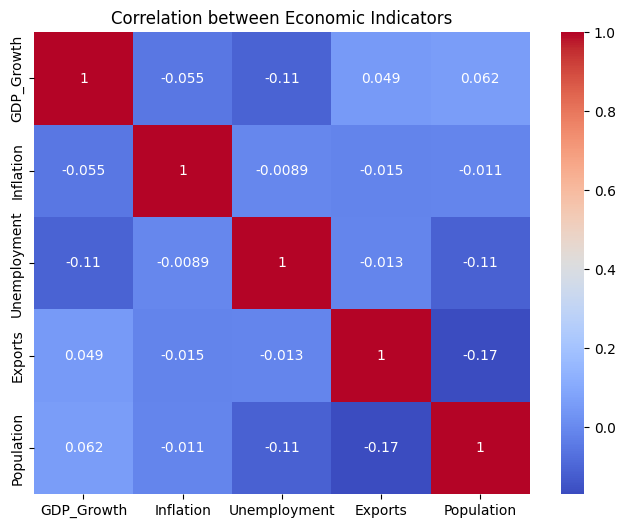

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["GDP_Growth","Inflation","Unemployment","Exports","Population"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation between Economic Indicators")

plt.show()

GDP growth shows weak correlation with other indicators, suggesting macroeconomic growth depends on multiple external factors.


In [3]:
df.groupby("Cluster")[["GDP_Growth","Inflation","Unemployment","Exports"]].mean()

,GDP_Growth,Inflation,Unemployment,Exports
Cluster,,,,
0,0.448800,0.001494,0.150265,0.124298
1,0.452810,0.000965,0.127894,0.379152
2,0.442386,0.001286,0.440137,0.165032


Cluster 0 → stable economies
Cluster 1 → high inflation economies
Cluster 2 → growth economies

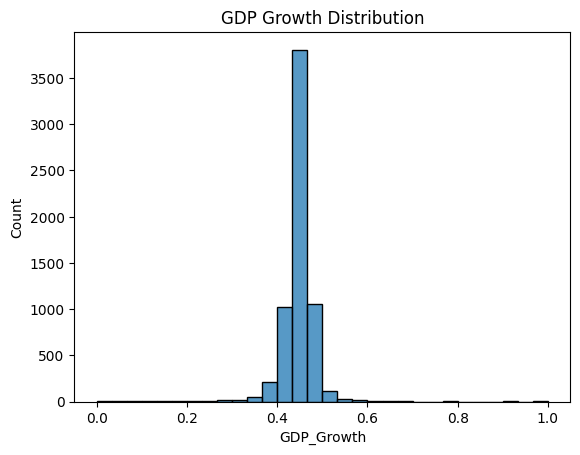

In [5]:
sns.histplot(df["GDP_Growth"], bins=30)
plt.title("GDP Growth Distribution")
plt.show()

most countries have GDP Growth between 0.4 - 0.6%

In [6]:
df.sort_values("GDP_Growth", ascending=False).head(10)

,Country Name,Country Code,Year,GDP,GDP_Growth,Inflation,Unemployment,Population,Exports,Economic_Health_Score,Cluster,PCA1,PCA2
3887,Libya,LBY,2012,9.254094e+10,1.000000,0.000963,0.489147,6179328.0,0.291991,0.760376,2,0.274314,0.150305
217,Kuwait,KWT,1992,1.985856e+10,0.973372,0.000686,0.020103,1634961.0,0.176712,0.820533,0,-0.187364,0.011168
6093,"Macao SAR, China",MAC,2023,4.562647e+10,0.923656,0.000729,0.054419,678800.0,0.403565,0.839146,1,-0.162957,0.238769
2314,Iraq,IRQ,2004,3.663367e+10,0.778350,0.001842,0.222610,27577878.0,0.245713,0.715592,0,0.017213,0.087649
5702,Maldives,MDV,2021,5.252457e+09,0.673112,0.000732,0.127028,516154.0,0.332303,0.710153,1,-0.079369,0.167878
1215,Iraq,IRQ,1998,2.061741e+10,0.656496,0.001329,0.205788,22884399.0,0.340164,0.689208,1,-0.000638,0.179474
2619,Azerbaijan,AZE,2006,2.098193e+10,0.652952,0.001059,0.168475,8484550.0,0.290402,0.685354,1,-0.035291,0.127851
367,Kuwait,KWT,1993,2.394139e+10,0.649798,0.000725,0.018088,1672151.0,0.208595,0.697876,0,-0.181236,0.038529
2395,Chad,TCD,2004,4.422856e+09,0.647405,0.000484,0.014780,9920036.0,0.222734,0.700456,0,-0.185173,0.052450
209,Iraq,IRQ,1992,5.536720e+08,0.640531,0.004223,0.213075,18300845.0,0.002520,0.613257,0,0.024001,-0.157562


Some smaller emerging economies show the highest growth rates.

In [7]:
df.sort_values("Inflation", ascending=False).head(10)

,Country Name,Country Code,Year,GDP,GDP_Growth,Inflation,Unemployment,Population,Exports,Economic_Health_Score,Cluster,PCA1,PCA2
471,"Congo, Dem. Rep.",COD,1994,5.820382e+09,0.398658,1.000000,0.085349,42626876.0,0.098782,0.362150,0,-0.101822,-0.072974
436,Ukraine,UKR,1993,6.564856e+10,0.330389,0.199738,0.049096,52350126.0,0.112986,0.504986,0,-0.136046,-0.060071
446,Armenia,ARM,1994,1.315159e+09,0.460299,0.142523,0.167959,3364610.0,0.171723,0.556368,0,-0.024186,0.006443
457,Belarus,BLR,1994,1.493144e+10,0.346959,0.094068,0.328165,10226955.0,0.311213,0.516580,2,0.132219,0.152378
460,Brazil,BRA,1994,5.253699e+11,0.463301,0.087968,0.167416,159265006.0,0.041520,0.542548,0,-0.018264,-0.123469
304,Brazil,BRA,1993,3.682958e+11,0.457149,0.081725,0.153230,156794577.0,0.045845,0.545037,0,-0.032452,-0.119938
523,Kazakhstan,KAZ,1994,2.125079e+10,0.340994,0.079623,0.192248,17043771.0,0.161839,0.514391,0,0.004194,-0.003701
449,Azerbaijan,AZE,1994,1.193141e+09,0.293935,0.070579,0.160207,7596550.0,0.107934,0.493004,0,-0.023674,-0.059769
301,Belarus,BLR,1993,1.627507e+10,0.374134,0.050739,0.217054,10239050.0,0.295250,0.555145,1,0.021312,0.131280
293,Azerbaijan,AZE,1993,1.570393e+09,0.271400,0.048124,0.113695,7494800.0,0.250917,0.526379,0,-0.076562,0.080409


High inflation often corresponds with economic instability.

In [ ]:
cluster_names = {
    0: "Stable Economies",
    1: "High Inflation Economies",
    2: "High Growth Economies"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

In [11]:
df[["Country Name","Cluster","Cluster_Name"]].head()

,Country Name,Cluster,Cluster_Name
0,Africa Eastern and Southern,0,Stable Economies
1,Australia,0,Stable Economies
2,Austria,0,Stable Economies
3,Belgium,1,High Inflation Economies
4,Burkina Faso,0,Stable Economies


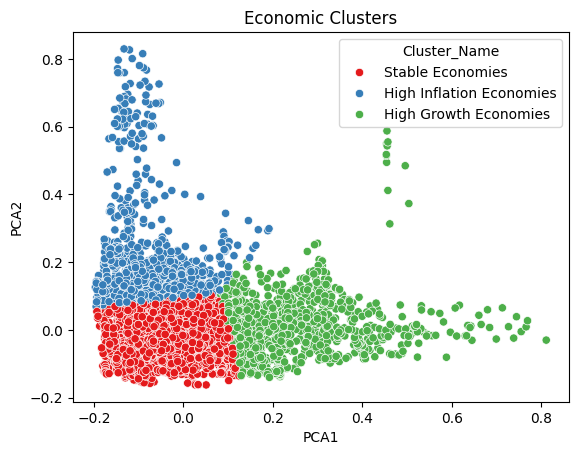

In [12]:
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster_Name",
    palette="Set1"
)

plt.title("Economic Clusters")

plt.show()

In [13]:
df.groupby("Cluster_Name")[["GDP_Growth","Inflation","Unemployment","Exports"]].mean()

,GDP_Growth,Inflation,Unemployment,Exports
Cluster_Name,,,,
High Growth Economies,0.442386,0.001286,0.440137,0.165032
High Inflation Economies,0.452810,0.000965,0.127894,0.379152
Stable Economies,0.448800,0.001494,0.150265,0.124298


In [14]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="Country Code",
    color="GDP_Growth",
    hover_name="Country Name",
    color_continuous_scale="Viridis"
)

fig.show()